Dataset: 958 rows | 2016-02-29 → 2019-12-16
Train: 766 rows | Test: 192 rows
  ✓ Scale check passed: test range [0.089, 0.955]
  ✓ Input shape:  (32, 60, 5)  → (batch, timesteps, features)
  ✓ Target shape: (32,)  → (batch,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 256)        │       268,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 465,537 (1.78 MB)

 Trainable params: 465,537 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 223ms/step - loss: 0.0301 - val_loss: 0.0347 - learning_rate: 0.0010
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 200ms/step - loss: 0.0064 - val_loss: 0.0063 - learning_rate: 0.0010
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 198ms/step - loss: 0.0049 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step - loss: 0.0058 - val_loss: 0.0314 - learning_rate: 0.0010
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - loss: 0.0083 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 200ms/step - loss: 0.0106 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 200ms/step - loss: 0.0065 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step - loss: 0.0051 - val_loss: 0.0074 - learning_rate: 0.0010
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step - loss: 0.0029 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 10/5

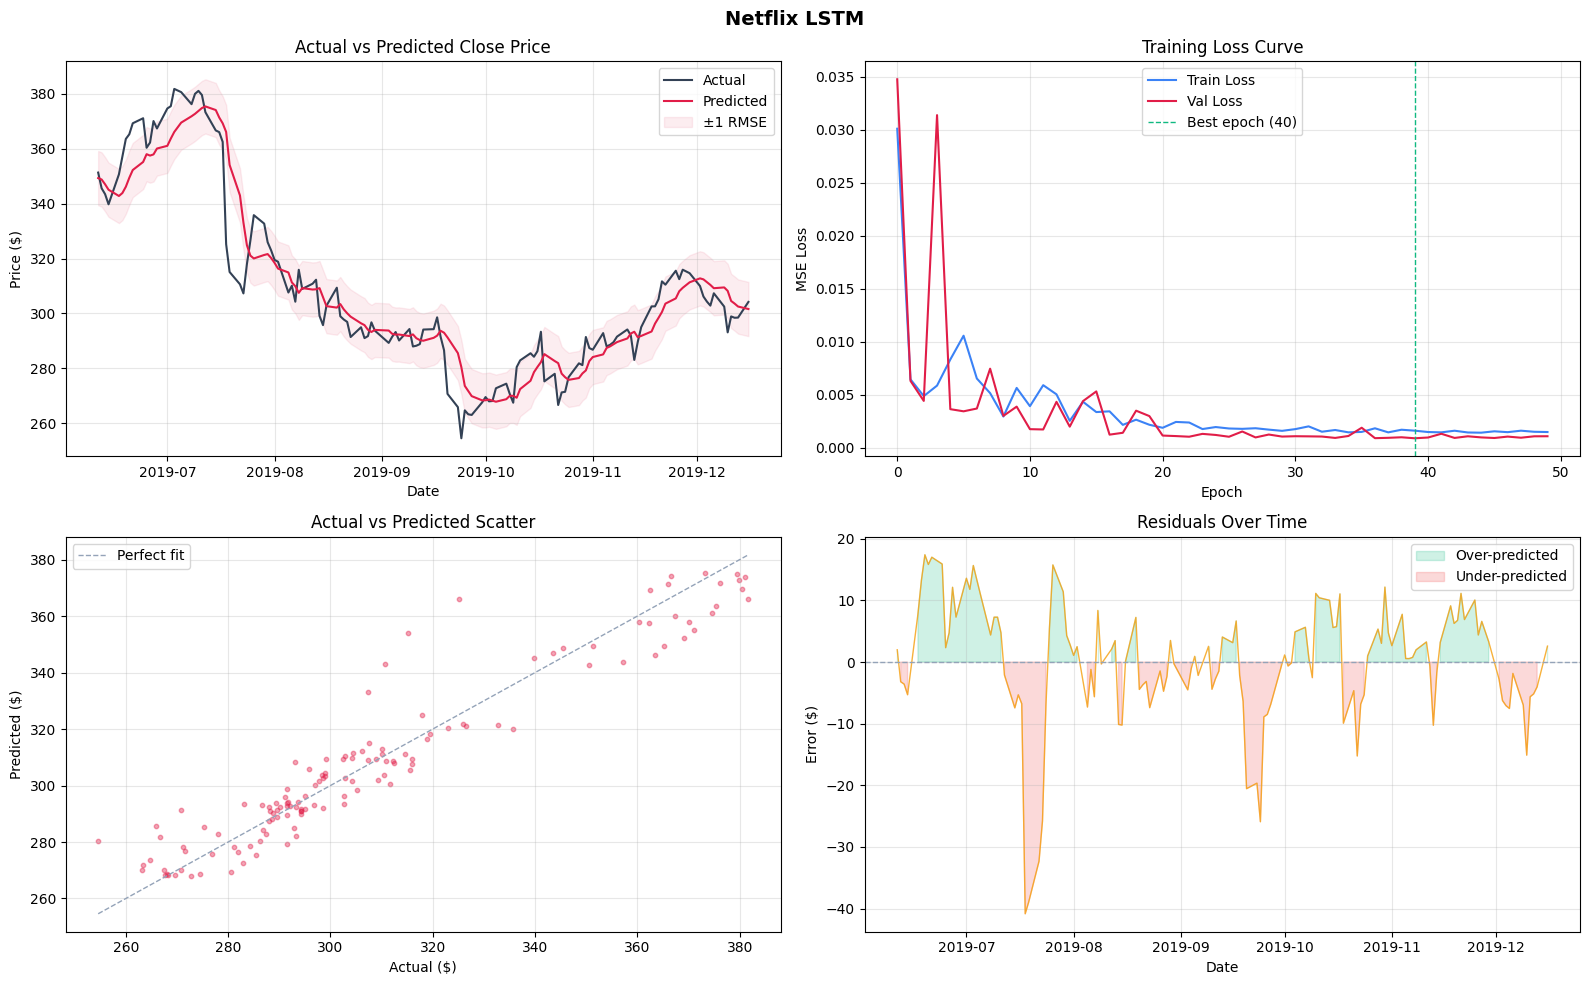


Plot saved → netflix_lstm_.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# ─────────────────────────────────────────────────────────────────────────────
# 1. LOAD & PARSE
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv('Netflix Stock Prices.csv')

df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=False)
df = df.sort_values('Date').reset_index(drop=True)

# ─────────────────────────────────────────────────────────────────────────────
# 2. FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────────────────────
df['Volume'] = np.log1p(df['Volume'])       # log-transform skewed volume
df['Return'] = df['Close'].pct_change()     # daily % return
df['MA10']   = df['Close'].rolling(10).mean()
df['MA50']   = df['Close'].rolling(50).mean()

df = df.dropna().reset_index(drop=True)

#  no NaNs should survive
assert df.isnull().sum().sum() == 0 # NaNs found after dropna 

print(f"Dataset: {len(df)} rows | {df['Date'].min().date()} → {df['Date'].max().date()}")

# ─────────────────────────────────────────────────────────────────────────────
# 3. TRAIN / TEST SPLIT  splitting BEFORE scaling
# ─────────────────────────────────────────────────────────────────────────────
features    = ['Close', 'Volume', 'MA10', 'MA50', 'Return']
data_arr    = df[features].values

SPLIT_RATIO      = 0.80
SEQUENCE_LENGTH  = 60
BATCH_SIZE       = 32

split_idx  = int(len(data_arr) * SPLIT_RATIO)
train_raw  = data_arr[:split_idx]
test_raw   = data_arr[split_idx:]

print(f"Train: {len(train_raw)} rows | Test: {len(test_raw)} rows")

# ─────────────────────────────────────────────────────────────────────────────
# 4. SCALE  — FIT ON TRAIN ONLY
# ─────────────────────────────────────────────────────────────────────────────

scaler       = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw)   # learns min/max from train only
test_scaled  = scaler.transform(test_raw)        # applies same scale to test

test_min, test_max = test_scaled.min(), test_scaled.max()
if test_min < -0.05 or test_max > 1.05:
    print(f"  ⚠ Test data slightly outside train range [{test_min:.3f}, {test_max:.3f}] — expected for rising stocks")
else:
    print(f"  ✓ Scale check passed: test range [{test_min:.3f}, {test_max:.3f}]")

# ─────────────────────────────────────────────────────────────────────────────
# 5. SEQUENCE GENERATORS
# ─────────────────────────────────────────────────────────────────────────────
train_gen = TimeseriesGenerator(
    train_scaled, train_scaled[:, 0],
    length=SEQUENCE_LENGTH,
    batch_size=BATCH_SIZE,
)
test_gen = TimeseriesGenerator(
    test_scaled, test_scaled[:, 0],
    length=SEQUENCE_LENGTH,
    batch_size=1,
)

# Confirm shapes before training — catches silent dimension mismatches
X_sample, y_sample = train_gen[0]
print(f"  ✓ Input shape:  {X_sample.shape}  → (batch, timesteps, features)")
print(f"  ✓ Target shape: {y_sample.shape}  → (batch,)")

# ─────────────────────────────────────────────────────────────────────────────
# 6. MODEL
# ─────────────────────────────────────────────────────────────────────────────
# explicit Input() layer — no more Keras 3 deprecation warning
# Adam with clipnorm=1.0 prevents the exploding gradients that caused
#      the val_loss spikes at epochs 23 and 38-39 in the original run
model = Sequential([
    Input(shape=(SEQUENCE_LENGTH, len(features))),
    LSTM(256, return_sequences=True),
    Dropout(0.2),
    LSTM(128),
    Dropout(0.2),
    Dense(1),
])

model.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss='mse',
)

model.summary()

# ─────────────────────────────────────────────────────────────────────────────
# 7. CALLBACKS
# ─────────────────────────────────────────────────────────────────────────────
# EarlyStopping with restore_best_weights=True means the model you get
#      back IS the best checkpoint — no separate file needed
# ReduceLROnPlateau halves the learning rate when val_loss plateaus,
#      which smooths out the spikes seen in the original training run
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,  # returns best epoch's weights automatically
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,       # halve LR on plateau
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
]

# ─────────────────────────────────────────────────────────────────────────────
# 8. TRAIN
# ─────────────────────────────────────────────────────────────────────────────
history = model.fit(
    train_gen,
    epochs=50,
    validation_data=test_gen,
    callbacks=callbacks,
    verbose=1,
)

best_epoch = np.argmin(history.history['val_loss']) + 1
print(f"\nBest epoch: {best_epoch} | Best val_loss: {min(history.history['val_loss']):.6f}")

# ─────────────────────────────────────────────────────────────────────────────
# 9. PREDICT & INVERSE TRANSFORM
# ─────────────────────────────────────────────────────────────────────────────
preds_scaled = model.predict(test_gen, verbose=0)


dummy_pred       = np.zeros((len(preds_scaled), len(features)))
dummy_pred[:, 0] = preds_scaled[:, 0]
predicted_prices = scaler.inverse_transform(dummy_pred)[:, 0]

dummy_actual       = np.zeros((len(test_scaled) - SEQUENCE_LENGTH, len(features)))
dummy_actual[:, 0] = test_scaled[SEQUENCE_LENGTH:, 0]
actual_prices      = scaler.inverse_transform(dummy_actual)[:, 0]

# ─────────────────────────────────────────────────────────────────────────────
# 10. EVALUATE
# ─────────────────────────────────────────────────────────────────────────────
rmse    = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
mae     = mean_absolute_error(actual_prices, predicted_prices)
mape    = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100
dir_acc = np.mean(
    np.sign(np.diff(actual_prices)) == np.sign(np.diff(predicted_prices))
) * 100

print(f"\n{'─'*40}")
print(f"  RMSE              : ${rmse:.2f}")
print(f"  MAE               : ${mae:.2f}")
print(f"  MAPE              : {mape:.2f}%")
print(f"  Directional Acc.  : {dir_acc:.1f}%")
print(f"{'─'*40}")

# ─────────────────────────────────────────────────────────────────────────────
# 11. PLOTS
# ─────────────────────────────────────────────────────────────────────────────
test_dates = df['Date'].values[split_idx + SEQUENCE_LENGTH:]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Netflix LSTM', fontsize=14, fontweight='bold')

# — Prediction vs actual
ax = axes[0, 0]
ax.plot(test_dates, actual_prices,    label='Actual',    color='#334155', linewidth=1.5)
ax.plot(test_dates, predicted_prices, label='Predicted', color='#e11d48', linewidth=1.5)
ax.fill_between(test_dates,
    predicted_prices - rmse, predicted_prices + rmse,
    color='#e11d48', alpha=0.08, label='±1 RMSE')
ax.set_title('Actual vs Predicted Close Price')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)

# — Training loss curve
ax = axes[0, 1]
ax.plot(history.history['loss'],     label='Train Loss', color='#3b82f6', linewidth=1.5)
ax.plot(history.history['val_loss'], label='Val Loss',   color='#e11d48', linewidth=1.5)
ax.axvline(best_epoch - 1, color='#10b981', linestyle='--', linewidth=1, label=f'Best epoch ({best_epoch})')
ax.set_title('Training Loss Curve')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# — Scatter: actual vs predicted
ax = axes[1, 0]
ax.scatter(actual_prices, predicted_prices, alpha=0.4, color='#e11d48', s=10)
lim = [min(actual_prices.min(), predicted_prices.min()),
       max(actual_prices.max(), predicted_prices.max())]
ax.plot(lim, lim, '--', color='#94a3b8', linewidth=1, label='Perfect fit')
ax.set_title('Actual vs Predicted Scatter')
ax.set_xlabel('Actual ($)')
ax.set_ylabel('Predicted ($)')
ax.legend()
ax.grid(True, alpha=0.3)

# — Residuals
ax = axes[1, 1]
residuals = actual_prices - predicted_prices
ax.plot(test_dates, residuals, color='#f59e0b', linewidth=1, alpha=0.8)
ax.axhline(0, color='#94a3b8', linestyle='--', linewidth=1)
ax.fill_between(test_dates, residuals, 0,
    where=(residuals > 0), color='#10b981', alpha=0.2, label='Over-predicted')
ax.fill_between(test_dates, residuals, 0,
    where=(residuals < 0), color='#ef4444', alpha=0.2, label='Under-predicted')
ax.set_title('Residuals Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Error ($)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('netflix_lstm_audit.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved → netflix_lstm_.png")

In [4]:
import pandas as pd
import numpy as np
import pickle

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG  — change these if needed
# ─────────────────────────────────────────────────────────────────────────────
CSV_PATH        = 'Netflix Stock Prices.csv'
MODEL_SAVE_PATH = 'netflix_lstm_model.keras'   # saved model
SCALER_SAVE_PATH= 'netflix_scaler.pkl'          # saved scaler
SPLIT_RATIO     = 0.80
SEQUENCE_LENGTH = 60
BATCH_SIZE      = 32
EPOCHS          = 50
FEATURES        = ['Close', 'Volume', 'MA10', 'MA50', 'Return']

# ─────────────────────────────────────────────────────────────────────────────
# 1. LOAD & PARSE
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=False)
df = df.sort_values('Date').reset_index(drop=True)

# ─────────────────────────────────────────────────────────────────────────────
# 2. FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────────────────────
df['Volume'] = np.log1p(df['Volume'])
df['Return'] = df['Close'].pct_change()
df['MA10']   = df['Close'].rolling(10).mean()
df['MA50']   = df['Close'].rolling(50).mean()
df = df.dropna().reset_index(drop=True)

assert df.isnull().sum().sum() == 0, "NaNs found after dropna — check your CSV"
print(f"Dataset: {len(df)} rows | {df['Date'].min().date()} → {df['Date'].max().date()}")

# ─────────────────────────────────────────────────────────────────────────────
# 3. SPLIT  (always before scaling)
# ─────────────────────────────────────────────────────────────────────────────
data_arr  = df[FEATURES].values
split_idx = int(len(data_arr) * SPLIT_RATIO)
train_raw = data_arr[:split_idx]
test_raw  = data_arr[split_idx:]
print(f"Train: {len(train_raw)} rows | Test: {len(test_raw)} rows")

# ─────────────────────────────────────────────────────────────────────────────
# 4. SCALE  — fit on train only
# ─────────────────────────────────────────────────────────────────────────────
scaler       = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw)
test_scaled  = scaler.transform(test_raw)

# ─────────────────────────────────────────────────────────────────────────────
# 5. GENERATORS
# ─────────────────────────────────────────────────────────────────────────────
train_gen = TimeseriesGenerator(
    train_scaled, train_scaled[:, 0],
    length=SEQUENCE_LENGTH, batch_size=BATCH_SIZE)
test_gen = TimeseriesGenerator(
    test_scaled, test_scaled[:, 0],
    length=SEQUENCE_LENGTH, batch_size=1)

X_sample, _ = train_gen[0]
print(f"✓ Input shape: {X_sample.shape}")

# ─────────────────────────────────────────────────────────────────────────────
# 6. MODEL
# ─────────────────────────────────────────────────────────────────────────────
model = Sequential([
    Input(shape=(SEQUENCE_LENGTH, len(FEATURES))),
    LSTM(256, return_sequences=True),
    Dropout(0.2),
    LSTM(128),
    Dropout(0.2),
    Dense(1),
])
model.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0), loss='mse')
model.summary()

# ─────────────────────────────────────────────────────────────────────────────
# 7. TRAIN
# ─────────────────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1),
]

history = model.fit(
    train_gen, epochs=EPOCHS,
    validation_data=test_gen,
    callbacks=callbacks, verbose=1,
)

best_epoch = np.argmin(history.history['val_loss']) + 1
print(f"\nBest epoch: {best_epoch} | val_loss: {min(history.history['val_loss']):.6f}")

# ─────────────────────────────────────────────────────────────────────────────
# 8. EVALUATE
# ─────────────────────────────────────────────────────────────────────────────
preds_scaled     = model.predict(test_gen, verbose=0)
dummy_pred       = np.zeros((len(preds_scaled), len(FEATURES)))
dummy_pred[:, 0] = preds_scaled[:, 0]
predicted_prices = scaler.inverse_transform(dummy_pred)[:, 0]

dummy_actual       = np.zeros((len(test_scaled) - SEQUENCE_LENGTH, len(FEATURES)))
dummy_actual[:, 0] = test_scaled[SEQUENCE_LENGTH:, 0]
actual_prices      = scaler.inverse_transform(dummy_actual)[:, 0]

rmse    = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
mae     = mean_absolute_error(actual_prices, predicted_prices)
mape    = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100
dir_acc = np.mean(np.sign(np.diff(actual_prices)) == np.sign(np.diff(predicted_prices))) * 100

print(f"\n{'─'*40}")
print(f"  RMSE             : ${rmse:.2f}")
print(f"  MAE              : ${mae:.2f}")
print(f"  MAPE             : {mape:.2f}%")
print(f"  Directional Acc. : {dir_acc:.1f}%")
print(f"{'─'*40}")

# ─────────────────────────────────────────────────────────────────────────────
# 9. SAVE MODEL + SCALER
# ─────────────────────────────────────────────────────────────────────────────
model.save(MODEL_SAVE_PATH)
print(f"✓ Model saved  → {MODEL_SAVE_PATH}")

with open(SCALER_SAVE_PATH, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ Scaler saved → {SCALER_SAVE_PATH}")

# Also save a small metadata file the app will use
import json
meta = {
    'sequence_length' : SEQUENCE_LENGTH,
    'features'        : FEATURES,
    'split_idx'       : split_idx,
    'rmse'            : round(float(rmse), 4),
    'mae'             : round(float(mae),  4),
    'mape'            : round(float(mape), 4),
    'dir_acc'         : round(float(dir_acc), 2),
    'best_epoch'      : int(best_epoch),
    'total_epochs'    : len(history.history['loss']),
    'train_loss'      : [round(v, 6) for v in history.history['loss']],
    'val_loss'        : [round(v, 6) for v in history.history['val_loss']],
    'date_min'        : str(df['Date'].min().date()),
    'date_max'        : str(df['Date'].max().date()),
}
with open('netflix_model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print(f"✓ Metadata saved → netflix_model_meta.json")
print("\nAll done. You can now run:  streamlit run app.py")

Dataset: 958 rows | 2016-02-29 → 2019-12-16
Train: 766 rows | Test: 192 rows
✓ Input shape: (32, 60, 5)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 256)        │       268,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 465,537 (1.78 MB)

 Trainable params: 465,537 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 211ms/step - loss: 0.0439 - val_loss: 0.0219 - learning_rate: 0.0010
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - loss: 0.0096 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 232ms/step - loss: 0.0042 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 192ms/step - loss: 0.0064 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - loss: 0.0051 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - loss: 0.0036 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - loss: 0.0028 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - loss: 0.0029 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - loss: 0.0028 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 10/5

In [7]:
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pickle, json, os

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# ─────────────────────────────────────────────────────────────────────────────
# PAGE CONFIG
# ─────────────────────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="NFLX Price Intelligence",
    page_icon="📈",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ─────────────────────────────────────────────────────────────────────────────
# CSS
# ─────────────────────────────────────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&family=JetBrains+Mono:wght@400;500&display=swap');

html, body, [class*="css"]    { font-family: 'Inter', sans-serif; }
.stApp                        { background: #ffffff; color: #1e293b; }
[data-testid="stSidebar"]     { background: #f8fafc !important; border-right: 1px solid #e2e8f0; }

.kpi        { background:#f8fafc; border:1px solid #e2e8f0; border-radius:10px; padding:18px 20px; text-align:center; }
.kpi-label  { font-size:10px; font-weight:600; letter-spacing:1.8px; text-transform:uppercase; color:#94a3b8; margin-bottom:6px; }
.kpi-value  { font-family:'JetBrains Mono',monospace; font-size:24px; font-weight:600; color:#0f172a; letter-spacing:-0.5px; }
.kpi-delta  { font-family:'JetBrains Mono',monospace; font-size:12px; margin-top:4px; }
.up         { color:#10b981; }
.down       { color:#ef4444; }

.eyebrow    { font-size:10px; font-weight:600; letter-spacing:2px; text-transform:uppercase; color:#e11d48; margin-bottom:4px; }
.heading    { font-size:22px; font-weight:700; color:#0f172a; margin-bottom:2px; }

hr          { border-color:#e2e8f0 !important; margin:20px 0; }

.stButton > button {
    background:#e11d48 !important; color:#fff !important;
    border:none !important; font-weight:600 !important;
    border-radius:8px !important; padding:10px 24px !important;
    letter-spacing:.4px; transition:opacity .18s;
}
.stButton > button:hover { opacity:.82 !important; }
[data-testid="stExpander"] { border:1px solid #e2e8f0 !important; border-radius:8px !important; }
</style>
""", unsafe_allow_html=True)

# ─────────────────────────────────────────────────────────────────────────────
# PLOTLY THEME
# ─────────────────────────────────────────────────────────────────────────────
PL = dict(
    paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="#f8fafc",
    font=dict(family="Inter,sans-serif", color="#475569", size=12),
    xaxis=dict(gridcolor="#e2e8f0", linecolor="#e2e8f0", zeroline=False),
    yaxis=dict(gridcolor="#e2e8f0", linecolor="#e2e8f0", zeroline=False),
    margin=dict(l=8, r=8, t=40, b=8),
    legend=dict(bgcolor="rgba(0,0,0,0)", bordercolor="#e2e8f0", borderwidth=1),
)

# ─────────────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def kpi(col, label, value, delta=None):
    d = ""
    if delta is not None:
        cls, arrow = ("up", "▲") if delta >= 0 else ("down", "▼")
        d = f'<div class="kpi-delta {cls}">{arrow} {abs(delta):.2f}%</div>'
    col.markdown(f"""
    <div class="kpi">
      <div class="kpi-label">{label}</div>
      <div class="kpi-value">{value}</div>
      {d}
    </div>""", unsafe_allow_html=True)

def prepare_data(df):
    """Feature engineering — same logic as train_and_save.py."""
    df = df.copy()
    df['Date']   = pd.to_datetime(df['Date'], format='mixed', dayfirst=False)
    df           = df.sort_values('Date').reset_index(drop=True)
    df['Volume'] = np.log1p(df['Volume'])
    df['Return'] = df['Close'].pct_change()
    df['MA10']   = df['Close'].rolling(10).mean()
    df['MA50']   = df['Close'].rolling(50).mean()
    return df.dropna().reset_index(drop=True)

@st.cache_resource
def load_artifacts():
    if (os.path.exists('netflix_lstm_model.keras') and
        os.path.exists('netflix_scaler.pkl') and
        os.path.exists('netflix_model_meta.json')):
        model = load_model('netflix_lstm_model.keras')
        with open('netflix_scaler.pkl', 'rb') as f:
            scaler = pickle.load(f)
        with open('netflix_model_meta.json') as f:
            meta = json.load(f)
        return model, scaler, meta
    return None, None, None

# ─────────────────────────────────────────────────────────────────────────────
# SIDEBAR
# ─────────────────────────────────────────────────────────────────────────────
with st.sidebar:
    st.markdown("### 📂 Data")
    uploaded_file = st.file_uploader("Upload Netflix CSV", type=["csv"])
    st.markdown("---")

    model, scaler, meta = load_artifacts()
    if model:
        st.success("Pre-trained model loaded ✓")
    else:
        st.info("No saved model found.\nRun `train_and_save.py` first,\nthen place the 3 output files\nnext to `app.py`.")

# ─────────────────────────────────────────────────────────────────────────────
# HEADER
# ─────────────────────────────────────────────────────────────────────────────
st.markdown('<p class="eyebrow">Deep Learning · Time Series Forecasting</p>', unsafe_allow_html=True)
st.markdown('<p class="heading">Netflix Stock Price Intelligence</p>', unsafe_allow_html=True)
st.caption("LSTM · Features: Close · Log Volume · MA10 · MA50 · Daily Return")
st.markdown("---")

# ─────────────────────────────────────────────────────────────────────────────
# GATE: need CSV to proceed
# ─────────────────────────────────────────────────────────────────────────────
if uploaded_file is None:
    st.info("⬅️  Upload your **Netflix Stock Prices CSV** in the sidebar to begin.")
    st.stop()

# FIX: read bytes immediately — don't pass UploadedFile into a cached function
raw_df = pd.read_csv(uploaded_file)
df     = prepare_data(raw_df)

FEATURES        = ['Close', 'Volume', 'MA10', 'MA50', 'Return']
SEQUENCE_LENGTH = 60
SPLIT_RATIO     = 0.80

# ─────────────────────────────────────────────────────────────────────────────
# KPI ROW
# ─────────────────────────────────────────────────────────────────────────────
latest  = df['Close'].iloc[-1]
prev    = df['Close'].iloc[-2]
first   = df['Close'].iloc[0]
pct_1d  = (latest - prev)  / prev  * 100
pct_all = (latest - first) / first * 100

c1, c2, c3, c4, c5 = st.columns(5)
kpi(c1, "Latest Close",  f"${latest:,.2f}", pct_1d)
kpi(c2, "All-Time High", f"${df['Close'].max():,.2f}")
kpi(c3, "All-Time Low",  f"${df['Close'].min():,.2f}")
kpi(c4, "Total Return",  f"{pct_all:+.1f}%")
kpi(c5, "Trading Days",  f"{len(df):,}")
st.markdown("")

# ─────────────────────────────────────────────────────────────────────────────
# HISTORICAL CHART
# ─────────────────────────────────────────────────────────────────────────────
st.markdown('<p class="eyebrow">Historical Data</p>', unsafe_allow_html=True)

fig_h = make_subplots(rows=2, cols=1, shared_xaxes=True,
                       row_heights=[0.72, 0.28], vertical_spacing=0.03)
fig_h.add_trace(go.Scatter(x=df['Date'], y=df['Close'],
    name="Close", line=dict(color="#e11d48", width=1.5)), row=1, col=1)
fig_h.add_trace(go.Scatter(x=df['Date'], y=df['MA10'],
    name="MA 10", line=dict(color="#3b82f6", width=1, dash='dot')), row=1, col=1)
fig_h.add_trace(go.Scatter(x=df['Date'], y=df['MA50'],
    name="MA 50", line=dict(color="#f59e0b", width=1, dash='dot')), row=1, col=1)
fig_h.add_trace(go.Bar(x=df['Date'], y=df['Return'], name="Daily Return",
    marker_color=np.where(df['Return'] >= 0, "#10b981", "#ef4444")), row=2, col=1)
fig_h.update_layout(**PL, height=430,
    title=dict(text="Closing Price + Moving Averages", font=dict(size=13, color="#0f172a")))
st.plotly_chart(fig_h, use_container_width=True)

st.markdown("---")

# ─────────────────────────────────────────────────────────────────────────────
# PREDICTIONS  (only if model is loaded)
# ─────────────────────────────────────────────────────────────────────────────
st.markdown('<p class="eyebrow">Model Predictions</p>', unsafe_allow_html=True)
st.markdown('<p class="heading">Actual vs Predicted</p>', unsafe_allow_html=True)
st.markdown("")

if model is None:
    st.warning("Run `train_and_save.py` to generate the model files, then relaunch the app.")
    st.stop()

data_arr  = df[FEATURES].values
split_idx = int(len(data_arr) * SPLIT_RATIO)

# Transform test data with the saved scaler (already fit on original train set)
test_scaled = scaler.transform(data_arr[split_idx:])

test_gen = TimeseriesGenerator(
    test_scaled, test_scaled[:, 0],
    length=SEQUENCE_LENGTH, batch_size=1)

preds_scaled     = model.predict(test_gen, verbose=0)
dummy_pred       = np.zeros((len(preds_scaled), len(FEATURES)))
dummy_pred[:, 0] = preds_scaled[:, 0]
predicted_prices = scaler.inverse_transform(dummy_pred)[:, 0]

dummy_actual       = np.zeros((len(test_scaled) - SEQUENCE_LENGTH, len(FEATURES)))
dummy_actual[:, 0] = test_scaled[SEQUENCE_LENGTH:, 0]
actual_prices      = scaler.inverse_transform(dummy_actual)[:, 0]

rmse    = meta['rmse']
mae     = meta['mae']
mape    = meta['mape']
dir_acc = meta['dir_acc']

# ── Eval KPIs ─────────────────────────────────────────────────────────────────
m1, m2, m3, m4 = st.columns(4)
kpi(m1, "RMSE",             f"${rmse:.2f}")
kpi(m2, "MAE",              f"${mae:.2f}")
kpi(m3, "MAPE",             f"{mape:.2f}%")
kpi(m4, "Directional Acc.", f"{dir_acc:.1f}%")
st.markdown("")

# ── Prediction chart ──────────────────────────────────────────────────────────
test_dates = df['Date'].values[split_idx + SEQUENCE_LENGTH:]

fig_p = go.Figure()
fig_p.add_trace(go.Scatter(x=test_dates, y=actual_prices,
    name="Actual", line=dict(color="#64748b", width=1.5)))
fig_p.add_trace(go.Scatter(x=test_dates, y=predicted_prices,
    name="Predicted", line=dict(color="#e11d48", width=1.8)))
fig_p.add_trace(go.Scatter(
    x=np.concatenate([test_dates, test_dates[::-1]]),
    y=np.concatenate([predicted_prices + rmse, (predicted_prices - rmse)[::-1]]),
    fill='toself', fillcolor='rgba(225,29,72,0.07)',
    line=dict(color='rgba(0,0,0,0)'), name="±1 RMSE band"))
fig_p.update_layout(**PL, height=400,
    title=dict(text="Test Set: Actual vs Predicted Close Price",
               font=dict(size=13, color="#0f172a")))
st.plotly_chart(fig_p, use_container_width=True)

# ── Loss curve + scatter side by side ─────────────────────────────────────────
col_l, col_s = st.columns(2)

with col_l:
    fig_loss = go.Figure()
    fig_loss.add_trace(go.Scatter(y=meta['train_loss'],
        name="Train", line=dict(color="#3b82f6", width=1.5)))
    fig_loss.add_trace(go.Scatter(y=meta['val_loss'],
        name="Val",   line=dict(color="#e11d48", width=1.5)))
    fig_loss.add_vline(x=meta['best_epoch'] - 1,
        line=dict(color="#10b981", dash="dash", width=1),
        annotation_text=f"Best (epoch {meta['best_epoch']})",
        annotation_font_color="#10b981")
    fig_loss.update_layout(**PL, height=310,
        title=dict(text=f"Training Loss — {meta['total_epochs']} epochs",
                   font=dict(size=13, color="#0f172a")))
    st.plotly_chart(fig_loss, use_container_width=True)

with col_s:
    lim = [min(actual_prices.min(), predicted_prices.min()),
           max(actual_prices.max(), predicted_prices.max())]
    fig_sc = go.Figure()
    fig_sc.add_trace(go.Scatter(x=actual_prices, y=predicted_prices,
        mode='markers', marker=dict(color="#e11d48", size=4, opacity=0.45),
        name="Points"))
    fig_sc.add_trace(go.Scatter(x=lim, y=lim, mode='lines',
        line=dict(color="#94a3b8", dash='dash', width=1), name="Perfect fit"))
    fig_sc.update_layout(**PL, height=310,
        title=dict(text="Actual vs Predicted Scatter",
                   font=dict(size=13, color="#0f172a")),
        xaxis_title="Actual ($)", yaxis_title="Predicted ($)")
    st.plotly_chart(fig_sc, use_container_width=True)

# ── Residuals ─────────────────────────────────────────────────────────────────
with st.expander("📐  Residual Analysis"):
    residuals = actual_prices - predicted_prices
    fig_r = make_subplots(rows=1, cols=2,
                subplot_titles=["Residuals over time", "Error distribution"])
    fig_r.add_trace(go.Scatter(x=list(range(len(residuals))), y=residuals,
        mode='lines', line=dict(color="#f59e0b", width=1)), row=1, col=1)
    fig_r.add_hline(y=0, line=dict(color="#94a3b8", dash="dash"), row=1, col=1)
    fig_r.add_trace(go.Histogram(x=residuals, nbinsx=40,
        marker_color="#e11d48", opacity=0.7), row=1, col=2)
    fig_r.update_layout(**PL, height=290, showlegend=False)
    st.plotly_chart(fig_r, use_container_width=True)
    st.caption(
        f"Mean error: ${residuals.mean():.2f}  |  "
        f"Std: ${residuals.std():.2f}  |  "
        f"Max over: ${residuals.max():.2f}  |  "
        f"Max under: ${residuals.min():.2f}"
    )

2026-06-11 12:55:48.935 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 12:55:48.941 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 12:55:48.946 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 12:55:48.950 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 12:55:48.959 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 12:55:48.965 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 12:55:48.965 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 12:55:48.970 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

ValueError: Invalid file path or buffer object type: <class 'NoneType'>